# School Performance and Deprivation

## Problem Definition and Objectives

The objective of this project is to investigate how regional deprivation affects school performance across England. By analysing Key Stage 4 (GCSE level) results alongside the 2019 Indices of Multiple Deprivation (IMD), we aim to identify the specific socio-economic factors that have the strongest impact on educational outcomes.

### Core Research Questions
1. Performance by Deprivation Level Over Time: How does overall school performance (Attainment 8 / Progress 8) vary between the most and least deprived Local Authorities, and has this attainment gap widened or narrowed between 2019 and 2025?

2. Specific Deprivation Factors: Among the different sub-domains of deprivation (Income, Employment, Health, Crime, Living Environment, Barriers to Housing), which specific factor has the strongest negative correlation with a region's educational outcomes?

3. Subject-Specific Resilience: Are there certain core EBacc subjects (e.g., Maths, Science) that are more resilient to the effects of deprivation compared to others (e.g., Humanities, Languages)?

4. The Gender Gap and Deprivation: How does the performance gap between boys and girls change across different levels of regional deprivation?

5. Language Background and Deprivation: How does the performance of pupils with English as an Additional Language (EAL) compare to first-language English speakers across different deprivation levels?

Machine Learning Questions:

6. Can You Predict a School's Progress 8 Band from Non-Academic Data Alone?


In [1]:
# Core library imports
import os
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Sourcing

We will download data directly from the official UK Government sources.

| Dataset | Source | Format |
|---------|--------|--------|
| IMD 2019 (File 7) | Ministry of Housing, Communities & Local Government | Direct CSV |
| KS4 Characteristics & Geography (2019-2025) | Department for Education — Explore Education Statistics API | Direct CSV |

In [2]:
# Create the data folder if it doesn't exist
os.makedirs("data", exist_ok=True)  # makedirs creates the directory "data", and exist_ok=True prevents an error if the folder already exists

# 1. English Indices of Deprivation 2019 (File 7 - LSOA scores, deciles, and denominators)
IoD_URL = "https://assets.publishing.service.gov.uk/media/5dc407b440f0b6379a7acc8d/File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv"
IoD_PATH = "data/File_7_IoD2019.csv" # The path where the IoD 2019 dataset will be saved

# 2. DfE KS4 Pupil Characteristics and Geography dataset (2018/19 up to 2024/25)
KS4_URL = "https://api.education.gov.uk/statistics/v1/data-sets/b3e19901-5d2b-b676-bb4c-e60937d74725/csv"
KS4_PATH = "data/ks4_characteristics_geography.csv" # The path where the KS4 Characteristics & Geography dataset will be saved

# Downloading IoD 2019 dataset
if not os.path.exists(IoD_PATH): # Check if the IoD dataset already exists to avoid unnecessary downloads
    print("Downloading IoD 2019 dataset (File 7)...")
    response = requests.get(IoD_URL) # Send a GET request to the IoD URL to download the dataset
    response.raise_for_status() # Check if the request was successful (status code 200). If not, it will raise an HTTPError.
    with open(IoD_PATH, "wb") as f: # Open the file to save the dataset and close it after writing (using 'with' ensures the file is properly closed)
        f.write(response.content)
    print("Saved data/File_7_IoD2019.csv")
else:
    print("data/File_7_IoD2019.csv already exists.")

# Downloading KS4 Characteristics & Geography dataset
if not os.path.exists(KS4_PATH):
    print("Downloading KS4 Characteristics & Geography dataset...")
    response = requests.get(KS4_URL)
    response.raise_for_status()
    with open(KS4_PATH, "wb") as f:
        f.write(response.content)
    print("Saved data/ks4_characteristics_geography.csv")
else:
    print("data/ks4_characteristics_geography.csv already exists.")

data/File_7_IoD2019.csv already exists.
data/ks4_characteristics_geography.csv already exists.


## Data Loading and Exploration

In this section, we will load our primary datasets:
1. **Indices of Multiple Deprivation (IMD) 2019:** Provides deprivation deciles and sub-domain scores for each Local Authority.
2. **DfE Key Stage 4 Pupil Characteristics and Geography:** Provides performance breakdowns by sex, language, and disadvantage status at Local Authority level from 2018/19 up to 2024/25.

In [3]:
# Load IoD dataset
iod_data = pd.read_csv(IoD_PATH, low_memory=False) # low_memory=False to avoid dtype warnings for large files

# Load KS4 Pupil Characteristics and Geography dataset
performance_data = pd.read_csv(KS4_PATH, low_memory=False) # low_memory=False to avoid dtype warnings for large files

print(f"IoD shape: {iod_data.shape}")
print(f"KS4 shape: {performance_data.shape}")

IoD shape: (32844, 57)
KS4 shape: (342410, 200)


## Initial Data Inspection

Now that the data is loaded, let's perform an initial inspection to understand the structure, check the column names, and look for any immediate data quality issues.

In [4]:
print("\n---IoD 2019 Info---")
print(iod_data.info())
print("--- IoD 2019 Dataset ---")
iod_data.head()


---IoD 2019 Info---
<class 'pandas.DataFrame'>
RangeIndex: 32844 entries, 0 to 32843
Data columns (total 57 columns):
 #   Column                                                                                              Non-Null Count  Dtype  
---  ------                                                                                              --------------  -----  
 0   LSOA code (2011)                                                                                    32844 non-null  str    
 1   LSOA name (2011)                                                                                    32844 non-null  str    
 2   Local Authority District code (2019)                                                                32844 non-null  str    
 3   Local Authority District name (2019)                                                                32844 non-null  str    
 4   Index of Multiple Deprivation (IMD) Score                                                           32

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,16364,5,1.503,1615,1,1296,175,656,465,715
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,22676,7,1.196,2969,1,1156,182,580,394,620
2,E01000003,City of London 001C,E09000001,City of London,19.402,14915,5,0.086,18510,6,...,17318,6,2.207,162,1,1350,146,759,445,804
3,E01000005,City of London 001E,E09000001,City of London,28.652,8678,3,0.211,6029,2,...,25218,8,1.769,849,1,1121,229,692,200,683
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.837,14486,5,0.117,14023,5,...,14745,5,0.969,4368,2,2040,522,1297,221,1285


In [5]:
print("\n--- Performance Info ---")
print(performance_data.info())
print("\n--- Performance Dataset ---")
performance_data.head()


--- Performance Info ---
<class 'pandas.DataFrame'>
RangeIndex: 342410 entries, 0 to 342409
Columns: 200 entries, time_period to qual_entries_without_discounting_average
dtypes: float64(10), int64(4), str(186)
memory usage: 522.5 MB
None

--- Performance Dataset ---


,time_period,time_identifier,geographic_level,country_code,country_name,region_code,region_name,old_la_code,new_la_code,la_name,...,valueaddedlan_sum,valueaddedlan_average,valueaddedlan_lower_95_ci,valueaddedlan_upper_95_ci,qual_entries_sum,qual_entries_average,gcse_entries_sum,gcse_entries_average,qual_entries_without_discounting_sum,qual_entries_without_discounting_average
0,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,4901678.49,7.8,4525185,7.2,4942447,7.9
1,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,2485577.91,7.8,2286227,7.1,2506494,7.8
2,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,2416100.58,7.9,2238958,7.3,2435953,8
3,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,253719.3,8,235518,7.5,254870,8.1
4,202425,Academic year,National,E92000001,England,NaN,NaN,NaN,NaN,NaN,...,z,z,z,z,123521.17,7.9,113991,7.3,124166,7.9


In [ ]:
# list of columns in datasets
print("\n--- IoD Columns ---")
print(iod_data.columns.tolist()) # Convert columns to list for better readability

print("\n--- Performance Columns ---")
print(performance_data.columns.tolist()) # Convert columns to list for better readability

The IMD dataset contains 57 variables and the KS4 dataset contains over 200 variables. Only variables relevant to the research questions will be retained.

In [7]:
#distinct values in geographic_level column of performance dataset
print("\n--- Geographic Level Distinct Values ---")
print(performance_data['geographic_level'].unique()) 


--- Geographic Level Distinct Values ---
<StringArray>
['National', 'Regional', 'Local authority']
Length: 3, dtype: str


There are three leveles ['National', 'Regional', 'Local authority']. We will have to isolate the dataset to Local Authority level later on.

In [8]:
# Get the unique values for breakdown_topic in the performance dataset
print("\n--- Unique Breakdown Topics in Performance Dataset ---")
print(performance_data['breakdown_topic'].unique())


--- Unique Breakdown Topics in Performance Dataset ---
<StringArray>
[                                                      'Total',
                                                         'Sex',
                                                   'Ethnicity',
                                            'Sex by ethnicity',
                                                  'FSM status',
                                           'Sex by FSM status',
                                     'Ethnicity by FSM status',
                              'Sex by ethnicity by FSM status',
                                               'SEN provision',
                                        'Sex by SEN provision',
                                  'Ethnicity by SEN provision',
                           'Sex by ethnicity by SEN provision',
                                 'FSM status by SEN provision',
                          'Sex by FSM status by SEN provision',
                                  

We will use the aggregates for Gender (Sex), Disadvantage (Disadvantage status), FSM (FSM status), and Language (First language) later on for Q4 and Q5

In [9]:
# Get the unique values for Sex in the performance dataset
print("\n--- Unique Sex Categories in Performance Dataset ---")
print(performance_data['sex'].unique()) # Get unique values in the 'sex' column to understand the different categories of sex available in the dataset

# Get the unique values for Disadvantage_status in the performance dataset
print("\n--- Unique Disadvantage Status Categories in Performance Dataset ---")
print(performance_data['disadvantage_status'].unique()) # Get unique values in the 'disadvantage_status' column to understand the different categories of disadvantage status available in the dataset

# Get the unique values for FSM_status in the performance dataset
print("\n--- Unique FSM Status Categories in Performance Dataset ---")
print(performance_data['fsm_status'].unique()) # Get unique values in the 'fsm_status' column to understand the different categories of FSM status available in the dataset

# Get the unique values for first language in the performance dataset
print("\n--- Unique First Language Categories in Performance Dataset ---")
print(performance_data['first_language'].unique()) # Get unique values in the 'first_language' column to understand the different categories of first language available in the dataset


--- Unique Sex Categories in Performance Dataset ---
<StringArray>
['Total', 'Boys', 'Girls']
Length: 3, dtype: str

--- Unique Disadvantage Status Categories in Performance Dataset ---
<StringArray>
['Total', 'Disadvantaged', 'Not known to be disadvantaged']
Length: 3, dtype: str

--- Unique FSM Status Categories in Performance Dataset ---
<StringArray>
['Total', 'FSM eligible', 'Not known to be FSM eligible']
Length: 3, dtype: str

--- Unique First Language Categories in Performance Dataset ---
<StringArray>
[                                     'Total',
            'Known or believed to be English',
 'Known or believed to be other than English']
Length: 3, dtype: str


## Data Selection – Variables Retained for Analysis

To address the five research questions, the original datasets were reduced substantially from approximately 200 performance variables and 57 deprivation variables to only those directly relevant to measuring educational outcomes, demographic differences, and deprivation indicators.

---

### Performance Dataset (`ks4_characteristics_geography.csv`)

The performance dataset contains Local Authority level Key Stage 4 outcomes. Variables retained differ depending on whether the analysis focuses on overall trends, subject-specific performance, or demographic breakdowns.


| Column                     | Purpose                                                    | Research Question(s) |
| ---------------------------| -----------------------------------------------------------| -------------------- |
| `time_period`              | Academic year used for trend analysis (2019–2025)          | Q1–Q5                |
| `new_la_code`              | Local Authority identifier used for merging datasets       | Q1–Q5                |
| `la_name`                  | Local Authority name for interpretation and visualisation  | Q1–Q5                |
| `pupil_count`              | Population size used for weighting and handling suppression| Q1–Q5                |
| `breakdown_topic`          | Indicates demographic grouping type                        | Q1-Q5                |
| `attainment8_average`      | Average Attainment 8 score                                 | Q1, Q2, Q4, Q5       |
| `progress8_average`        | Average Progress 8 score                                   | Q1, Q2, Q4, Q5       |
| `ebacc_aps_average`        | Overall EBacc Average Point Score                          | Q1, Q4, Q5           |
| `attainment8eng_average`   | Attainment 8 English component                             | Q3                   |
| `attainment8mat_average`   | Attainment 8 Maths component                               | Q3                   |
| `attainment8ebacc_average` | Attainment 8 EBacc component                               | Q3                   |
| `progress8eng_average`     | Progress 8 English component                               | Q3                   |
| `progress8mat_average`     | Progress 8 Maths component                                 | Q3                   |
| `progress8ebacc_average`   | Progress 8 EBacc component                                 | Q3                   |
| `progress8open_average`    | Progress 8 Open component                                  | Q3                   |
| `ebacceng_aps_average`     | EBacc English APS                                          | Q3                   |
| `ebaccmat_aps_average`     | EBacc Maths APS                                            | Q3                   |
| `ebaccsci_aps_average`     | EBacc Science APS                                          | Q3                   |
| `ebacchum_aps_average`     | EBacc Humanities APS                                       | Q3                   |
| `ebacclan_aps_average`     | EBacc Languages APS                                        | Q3                   |
| `sex`                      | Gender grouping variable                                   | Q4                   |
| `disadvantage_status`      | Disadvantaged / non-disadvantaged grouping                 | Supporting analysis  |
| `fsm_status`               | Free school meal eligibility grouping                      | Supporting analysis  |
| `first_language`           | First language / EAL grouping variable                     | Q5                   |
| `pupil_count`              | Number of pupils within subgroup                           | Q4, Q5               |
| `attainment8_average`      | Average Attainment 8 score by subgroup                     | Q4, Q5               |
| `progress8_average`        | Average Progress 8 score by subgroup                       | Q4, Q5               |
| `ebacc_aps_average`        | Average EBacc APS by subgroup                              | Q4, Q5               |
---


### Deprivation Dataset (`File_7_IoD2019.csv`)

The deprivation dataset provides Local Authority measures used to quantify regional socioeconomic disadvantage and investigate which factors most strongly relate to educational outcomes.

| Column                                                             | Description                                 | Research Question(s) |
| ------------------------------------------------------------------ | ------------------------------------------- | -------------------- |
| `Local Authority District code (2019)`                             | Local Authority identifier used for merging | Q1–Q5                |
| `Local Authority District name (2019)`                             | Local Authority name                        | Q1–Q5                |
| `Index of Multiple Deprivation (IMD) Score`                        | Overall deprivation measure                 | Q1                   |
| `Income Score (rate)`                                              | Income deprivation indicator                | Q2                   |
| `Employment Score (rate)`                                          | Employment deprivation indicator            | Q2                   |
| `Education, Skills and Training Score`                             | Education deprivation indicator             | Q2                   |
| `Health Deprivation and Disability Score`                          | Health deprivation indicator                | Q2                   |
| `Crime Score`                                                      | Crime deprivation indicator                 | Q2                   |
| `Barriers to Housing and Services Score`                           | Housing accessibility indicator             | Q2                   |
| `Living Environment Score`                                         | Environmental deprivation indicator         | Q2                   |
| `Income Deprivation Affecting Children Index (IDACI) Score (rate)` | Child poverty indicator                     | Q2                   |
| `Children and Young People Sub-domain Score`                       | Education-related deprivation measure       | Q2                   |
| `Total population: mid 2015 (excluding prisoners)`                 | Total population                            | Q2                   |

---

> **Data Reduction Note:**
> All other variables from both datasets were removed to reduce dimensionality and retain only variables directly relevant to the research questions. 

In [10]:

cols_imd = ['LSOA code (2011)',
'LSOA name (2011)',
'Local Authority District code (2019)',
'Local Authority District name (2019)',           
'Index of Multiple Deprivation (IMD) Score',
'Income Score (rate)',
'Employment Score (rate)',
'Education, Skills and Training Score',
'Health Deprivation and Disability Score',
'Crime Score',
'Barriers to Housing and Services Score',
'Living Environment Score',
'Income Deprivation Affecting Children Index (IDACI) Score (rate)',
'Children and Young People Sub-domain Score',
'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)',
'Total population: mid 2015 (excluding prisoners)']
imd_data = iod_data[cols_imd].copy()


### Isolating Local Authority Data

First, we filter the KS4 dataset to only include data at the Local Authority level, as our deprivation data is mapped to Local Authorities.

In [11]:
# Filter performance data to Local authority level
df_loc = performance_data[performance_data["geographic_level"] == "Local authority"].copy()
print(df_loc.shape)
#df_loc.head()

(293223, 200)


We have isolated the dataset to Local Authority level. Next, we will create the base dataset for Q1, Q2, and Q3, picking the overall and subject-specific metrics.

### Creating the Overall and Subject-Specific Dataset (Q1, Q2, Q3)

We extract overall measures (`attainment8_average`, `progress8_average`) and subject-specific measures. We use the `Total` breakdown here, meaning we are looking at the overall student population in that area, not split by gender or disadvantage.

In [12]:
cols_total = [
    'time_period',
    'new_la_code',
    'la_name',
    'pupil_count',
    'attainment8_average',
    'progress8_average',
    'ebacc_aps_average',
    'attainment8eng_average', 
    'attainment8mat_average', 
    'attainment8ebacc_average', 
    'progress8eng_average', 
    'progress8mat_average', 
    'progress8ebacc_average', 
    'progress8open_average', 
    'ebacceng_aps_average', 
    'ebaccmat_aps_average', 
    'ebaccsci_aps_average', 
    'ebacchum_aps_average', 
    'ebacclan_aps_average',
    'ebacceng_entering_percent',
    "ebaccmat_entering_percent",
    "ebaccsci_entering_percent",
    "ebacchum_entering_percent",
    "ebacclan_entering_percent"
]

# Filter to 'Total' breakdown
df_total = df_loc[df_loc["breakdown_topic"] == "Total"].copy()
df_total = df_total[cols_total]

# Check the shape
print("Shape of Q1/Q2/Q3 dataset:", df_total.shape)
print(df_total.info())
print(df_total.head())


Shape of Q1/Q2/Q3 dataset: (1058, 24)
<class 'pandas.DataFrame'>
Index: 1058 entries, 5939 to 342131
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   time_period                1058 non-null   int64  
 1   new_la_code                1058 non-null   str    
 2   la_name                    1058 non-null   str    
 3   pupil_count                1058 non-null   int64  
 4   attainment8_average        1058 non-null   str    
 5   progress8_average          1058 non-null   str    
 6   ebacc_aps_average          1058 non-null   str    
 7   attainment8eng_average     1058 non-null   str    
 8   attainment8mat_average     1058 non-null   str    
 9   attainment8ebacc_average   1058 non-null   str    
 10  progress8eng_average       1058 non-null   str    
 11  progress8mat_average       1058 non-null   str    
 12  progress8ebacc_average     1058 non-null   str    
 13  progress8open_average

### Handling Missing Data and Data Types
In both datasets we don't have missing data, but in DfE dataset we have 'z' values instead of Nulls.

In [13]:
nulls = iod_data.isnull().sum()
print("missing values in IDM dataset:", len(nulls[nulls > 0]))
nulls = df_loc.isnull().sum()
print("missing values in DfE dataset:", len(nulls[nulls > 0]))

missing values in IDM dataset: 0
missing values in DfE dataset: 0


In [14]:
# Count total values, z values, and percentage of z values
z_summary = pd.DataFrame({
    'total_values': df_total.count(),
    'z_count': (df_total == 'z').sum() 
})

# Calculate percentage of z values
z_summary['z_percentage'] = (z_summary['z_count'] / z_summary['total_values']) * 100

# Round percentages
z_summary['z_percentage'] = z_summary['z_percentage'].round(2)

# Display results
z_summary

,total_values,z_count,z_percentage
time_period,1058,0,0.00
new_la_code,1058,0,0.00
la_name,1058,0,0.00
pupil_count,1058,0,0.00
attainment8_average,1058,0,0.00
progress8_average,1058,453,42.82
ebacc_aps_average,1058,0,0.00
attainment8eng_average,1058,0,0.00
attainment8mat_average,1058,0,0.00
attainment8ebacc_average,1058,0,0.00


All Progress 8 variables have about **453 missing values (around 42.82%, shown as "z")**.

This level of missing data is too high for reliable analysis, especially for:
- correlations with deprivation
- comparisons over time (2019–2025)
- comparisons across Local Authorities

Keeping these variables could lead to biased or misleading results.

As a result, all Progress 8 variables were removed from the dataset.

We now focus on:
- Attainment 8 measures  
- EBacc Average Point Score (APS)  
- Subject-specific attainment measures  

This improves the reliability and completeness of the analysis.

In [15]:
progress_cols = [
    'progress8_average',
    'progress8eng_average',
    'progress8mat_average',
    'progress8ebacc_average',
    'progress8open_average'
]

df_total = df_total.drop(columns=progress_cols)

Some performance columns are currently stored as text (`str`) even though they contain numbers.

These will be converted to `float` so we can use them for calculations, graphs, and analysis.

In [16]:
cols_to_float = [
    'attainment8_average',
    'ebacc_aps_average',
    'attainment8eng_average',
    'attainment8mat_average',
    'attainment8ebacc_average',
    'ebacceng_aps_average',
    'ebaccmat_aps_average',
    'ebaccsci_aps_average',
    'ebacchum_aps_average',
    'ebacclan_aps_average',
    'ebacceng_entering_percent',
    "ebaccmat_entering_percent",
    "ebaccsci_entering_percent",
    "ebacchum_entering_percent",
    "ebacclan_entering_percent"   
]

df_total[cols_to_float] = df_total[cols_to_float].astype(float)

# Checking datatypes to ensure they are now float64
print(df_total.dtypes)

time_period                    int64
new_la_code                      str
la_name                          str
pupil_count                    int64
attainment8_average          float64
ebacc_aps_average            float64
attainment8eng_average       float64
attainment8mat_average       float64
attainment8ebacc_average     float64
ebacceng_aps_average         float64
ebaccmat_aps_average         float64
ebaccsci_aps_average         float64
ebacchum_aps_average         float64
ebacclan_aps_average         float64
ebacceng_entering_percent    float64
ebaccmat_entering_percent    float64
ebaccsci_entering_percent    float64
ebacchum_entering_percent    float64
ebacclan_entering_percent    float64
dtype: object


Data types are now correctly set to `float64`, allowing numerical analysis.

We will now create an `end_year` column from `time_period` to make the time variable easier to interpret and use in trend analysis and visualisation.

In [17]:
df_total['end_year'] = 2000 + df_total['time_period'].astype(str).str[4:].astype(int)

### Creating Demographic Gap Datasets (Q4 & Q5)

We extract separate dataframes for Gender (`Sex`), Disadvantage (`Disadvantage status`), FSM (`FSM status`), and Language (`First language`).

In [18]:
df_gender = df_loc[df_loc["breakdown_topic"] == "Sex"].copy()
df_disadv = df_loc[df_loc["breakdown_topic"] == "Disadvantage status"].copy()
df_fsm = df_loc[df_loc["breakdown_topic"] == "FSM status"].copy()
df_lang = df_loc[df_loc["breakdown_topic"] == "First language"].copy()

# Check the shapes of the filtered datasets
print(f"Gender dataset shape: {df_gender.shape}")
print(f"Disadvantage dataset shape: {df_disadv.shape}")
print(f"FSM dataset shape: {df_fsm.shape}")
print(f"Language dataset shape: {df_lang.shape}")

Gender dataset shape: (2116, 200)
Disadvantage dataset shape: (2116, 200)
FSM dataset shape: (2114, 200)
Language dataset shape: (2109, 200)


#### Trimming Demographic Datasets to Relevant Columns

Just as with `df_total`, we now reduce each demographic dataframe from 200 columns down to only those needed for Q4 and Q5. We keep:

- **Core identifiers**: `time_period`, `new_la_code`, `la_name`, `pupil_count`
- **Demographic label**: the specific breakdown column for each dataframe (`sex`, `disadvantage_status`, `fsm_status`, or `first_language`)
- **Performance metrics**: the same attainment and subject-level averages used in `df_total`

Note: Progress 8 columns are excluded for the same reason as in `df_total` — ~43% missing values (`z`) make them unreliable for analysis.

In [19]:
# Core identifier columns shared across all demographic dataframes
core_cols = [
    'time_period',
    'new_la_code',
    'la_name',
    'pupil_count',
]

# Performance metric columns (same set as df_total, Progress 8 excluded)
perf_cols = [
    'attainment8_average',
    'ebacc_aps_average',
    'attainment8eng_average',
    'attainment8mat_average',
    'attainment8ebacc_average',
    'ebacceng_aps_average',
    'ebaccmat_aps_average',
    'ebaccsci_aps_average',
    'ebacchum_aps_average',
    'ebacclan_aps_average',
]

# Trim each demographic dataframe to relevant columns only
df_gender = df_gender[core_cols + ['sex']                 + perf_cols].copy()
df_disadv = df_disadv[core_cols + ['disadvantage_status'] + perf_cols].copy()
df_fsm    = df_fsm   [core_cols + ['fsm_status']          + perf_cols].copy()
df_lang   = df_lang  [core_cols + ['first_language']       + perf_cols].copy()

print(f"df_gender: {df_gender.shape[0]} rows, {df_gender.shape[1]} columns")
print(f"df_disadv: {df_disadv.shape[0]} rows, {df_disadv.shape[1]} columns")
print(f"df_fsm:    {df_fsm.shape[0]} rows, {df_fsm.shape[1]} columns")
print(f"df_lang:   {df_lang.shape[0]} rows, {df_lang.shape[1]} columns")

df_gender: 2116 rows, 15 columns
df_disadv: 2116 rows, 15 columns
df_fsm:    2114 rows, 15 columns
df_lang:   2109 rows, 15 columns


In [20]:
# Convert performance columns from str to float (same treatment as df_total)
for df in [df_gender, df_disadv, df_fsm, df_lang]:
    df[perf_cols] = df[perf_cols].apply(pd.to_numeric, errors='coerce')

# Add end_year column derived from time_period (e.g. 202425 -> 2025)
for df in [df_gender, df_disadv, df_fsm, df_lang]:
    df['end_year'] = 2000 + df['time_period'].astype(str).str[4:].astype(int)

# Verify dtypes on one dataframe as a spot-check
print(df_gender.dtypes)

time_period                   int64
new_la_code                     str
la_name                         str
pupil_count                   int64
sex                             str
attainment8_average         float64
ebacc_aps_average           float64
attainment8eng_average      float64
attainment8mat_average      float64
attainment8ebacc_average    float64
ebacceng_aps_average        float64
ebaccmat_aps_average        float64
ebaccsci_aps_average        float64
ebacchum_aps_average        float64
ebacclan_aps_average        float64
end_year                      int64
dtype: object


After converting to float (which ran as coerced), any z values changed to NaN. Any remaining NaN need analysis at this point.

In [21]:
for name, df in [('df_total', df_total), 
                 ('df_gender', df_gender),
                 ('df_disadv', df_disadv), 
                 ('df_fsm', df_fsm), 
                 ('df_lang', df_lang)]:
    print(f"--- {name} ---")
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    if len(null_counts) == 0:
        print("No missing values")
    else:
        total = len(df)
        print(pd.DataFrame({
            'missing': null_counts,
            'percent': (null_counts / total * 100).round(2)
        }))

--- df_total ---
No missing values
--- df_gender ---
No missing values
--- df_disadv ---
                      missing  percent
ebacchum_aps_average        1     0.05
ebacclan_aps_average        4     0.19
--- df_fsm ---
                      missing  percent
ebacchum_aps_average        1     0.05
ebacclan_aps_average        5     0.24
--- df_lang ---
No missing values


Several datasets have no missing data, including df_total, df_gender, and df_lang. The two datasets which do contain missing values, have a very low level of missingness (<0.25%).

If these are missing across different LA's and different years, then it is likely random, and we can justify filling in with the group median. However, if it is the same LA, then it is structural missingness and this data should be dropped (and acknowledged).

In [ ]:
# df_disadv
print("=== df_disadv missing ===")
print(df_disadv[df_disadv['ebacchum_aps_average'].isnull() | 
                df_disadv['ebacclan_aps_average'].isnull()]
      [['la_name', 'end_year', 'disadvantage_status', 
        'ebacchum_aps_average', 'ebacclan_aps_average']])

# df_fsm
print("\n--- df_fsm missing ---")
print(df_fsm[df_fsm['ebacchum_aps_average'].isnull() | 
             df_fsm['ebacclan_aps_average'].isnull()]
     [['la_name', 'end_year', 'fsm_status',
       'ebacchum_aps_average', 'ebacclan_aps_average']])

for name, df in [('df_total', df_total), ('df_gender', df_gender),
                 ('df_disadv', df_disadv), ('df_fsm', df_fsm), 
                 ('df_lang', df_lang)]:
    count = (df['la_name'] == 'Isles of Scilly').sum()
    print(f"{name}: {count} Isles of Scilly rows")

In both datasets, it is the Isles of Scilly that have the missing data. This is a very small local authority (total population of ~2,000 people). This is likely to be the reason for  the observed missing data: systematic suppression of subject-level data arising from small cohort sizes. 

For consistency, therefore, it is also dropped from the primary dataset to ensure consistency across research questions. 

In [23]:
for df in [df_total, df_gender, df_disadv, df_fsm, df_lang]:
    before = len(df)
    df.drop(df[df['la_name'] == 'Isles of Scilly'].index, inplace=True)
    print(f"Dropped {before - len(df)} rows")

Dropped 7 rows
Dropped 14 rows
Dropped 14 rows
Dropped 12 rows
Dropped 7 rows


# Merging two datasets 


Before merging the datasets, we examined the geographic levels and authority codes used in each dataset to determine whether a direct match was possible.

In [24]:
dfe_codes = set(df_loc["new_la_code"].dropna().astype(str).str.strip())
imd_district_codes = set(imd_data["Local Authority District code (2019)"].dropna().astype(str).str.strip())

print("DfE authority codes:", len(dfe_codes))
print("IMD district codes:", len(imd_district_codes))
print("Matching codes before lookup:", len(dfe_codes & imd_district_codes))
print("Only in DfE:", len(dfe_codes - imd_district_codes))
print("Only in IMD:", len(imd_district_codes - dfe_codes))

DfE authority codes: 157
IMD district codes: 317
Matching codes before lookup: 124
Only in DfE: 33
Only in IMD: 193


The initial code comparison showed that many DfE authority codes did not directly match the IMD district codes.

The DfE school performance dataset and IMD deprivation dataset use different geographic levels. The DfE dataset reports results at Upper Tier Local Authority level, including county councils, unitary authorities, London boroughs and metropolitan boroughs. The IMD dataset is published at LSOA level and includes the same unitary authorities, London boroughs and metropolitan boroughs but instead of county councils use Local Authority District:
DfE         |         IMD
------------|---------------------
Kent        |      Ashford
Kent        |      Canterbury
York        |      York
Bromley     |      Bromley
Manchester  |      Manchester
Leicester   |      Leicester

So the two datasets cannot be merged directly. To align them, an ONS lookup table was used to map Local Authority Districts to their corresponding County / Unitary Authority geography (CTYUA). IMD values were then aggregated to this level before merging with the DfE data.

In [25]:
lookup_path = "data/Look_up.csv"

if not os.path.exists(lookup_path):
    print("Downloading ONS Lookup Table...")

    url = (
        "https://hub.arcgis.com/api/v3/datasets/"
        "fdddaa25a0df4679b496620557cca534_0/downloads/data"
        "?format=csv&spatialRefId=4326"
    )

    df = pd.read_csv(url)
    df.to_csv(lookup_path, index=False)

    print("Download complete!")
else:
    print("Look_up.csv already exists in the data/ folder.")

Look_up.csv already exists in the data/ folder.


In [26]:
df_lookup = pd.read_csv('data/Look_up.csv')
df_lookup.tail()

,FID,LTLA19CD,LTLA19NM,UTLA19CD,UTLA19NM
334,335,E07000071,Colchester,E10000012,Essex
335,336,E07000072,Epping Forest,E10000012,Essex
336,337,E07000073,Harlow,E10000012,Essex
337,338,E07000074,Maldon,E10000012,Essex
338,339,E07000075,Rochford,E10000012,Essex


In [27]:
# Merge IMD district data with lookup
imd_lookup = imd_data.merge(
    df_lookup,
    left_on="Local Authority District code (2019)",
    right_on="LTLA19CD",
    how="left" 
)
print("Merged IMD with Lookup shape:", imd_lookup.shape)

Merged IMD with Lookup shape: (32844, 21)


In [28]:
print("Unmatched IMD rows after lookup:", imd_lookup["LTLA19CD"].isna().sum())
print("Unique IMD districts:", iod_data["Local Authority District code (2019)"].nunique())
print("Unique matched districts:", imd_lookup["LTLA19CD"].nunique())

Unmatched IMD rows after lookup: 0
Unique IMD districts: 317
Unique matched districts: 317


To aggregate LSOA-level deprivation indicators to Local Authority level (the geographic level used in the DfE dataset), population-weighted averages were calculated. Comparison with simple arithmetic means showed only minor differences due to the relatively consistent population sizes of LSOAs. For example, for Kent the unweighted average IMD score was 19.50, compared with a population-weighted average score of 19.54. However, weighted averages were retained as they provide a more statistically appropriate aggregation method and align with best practice for combining population-based indicators.

In [29]:
imd_lookup["Total population: mid 2015 (excluding prisoners)"].describe() 
# population sizes of LSOAs are clustered around 1400 - 1800, 
# that's why weighted and unweighted average imd parameters are very similar.

count    32844.000000
mean      1666.307514
std        363.622458
min        523.000000
25%       1446.000000
50%       1598.000000
75%       1800.000000
max       9551.000000
Name: Total population: mid 2015 (excluding prisoners), dtype: float64

In [30]:
imd_lookup["highly_deprived"] = (
    imd_lookup['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)'] <= 2
)
def weighted_mean(group, col):
    return np.average(group[col], weights=group['Total population: mid 2015 (excluding prisoners)'])

imd_agg = (
    imd_lookup.groupby(["UTLA19CD", "UTLA19NM"]).apply(lambda gr: pd.Series({
        "pct_highly_deprived": gr["highly_deprived"].mean() * 100,
        "imd_score": weighted_mean(gr, "Index of Multiple Deprivation (IMD) Score"),
        "income_score": weighted_mean(gr, "Income Score (rate)"),
        "employment_score": weighted_mean(gr, "Employment Score (rate)"),
        "education_score": weighted_mean(gr, "Education, Skills and Training Score"),
        "health_score": weighted_mean(gr, "Health Deprivation and Disability Score"),
        "crime_score": weighted_mean(gr, "Crime Score"),
        "barriers_score": weighted_mean(gr, "Barriers to Housing and Services Score"),
        "living_env_score": weighted_mean(gr, "Living Environment Score"),
        "idaci_score": weighted_mean(gr, "Income Deprivation Affecting Children Index (IDACI) Score (rate)"),
        "children_subdomain": weighted_mean(gr, "Children and Young People Sub-domain Score"),
        "total_population": gr['Total population: mid 2015 (excluding prisoners)'].sum()
    }))
    .reset_index()
)
print("---NEW DEPRIVATION DATA STRUCTURE ------")
print(imd_agg.info())

---NEW DEPRIVATION DATA STRUCTURE ------
<class 'pandas.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UTLA19CD             151 non-null    str    
 1   UTLA19NM             151 non-null    str    
 2   pct_highly_deprived  151 non-null    float64
 3   imd_score            151 non-null    float64
 4   income_score         151 non-null    float64
 5   employment_score     151 non-null    float64
 6   education_score      151 non-null    float64
 7   health_score         151 non-null    float64
 8   crime_score          151 non-null    float64
 9   barriers_score       151 non-null    float64
 10  living_env_score     151 non-null    float64
 11  idaci_score          151 non-null    float64
 12  children_subdomain   151 non-null    float64
 13  total_population     151 non-null    float64
dtypes: float64(12), str(2)
memory usage: 16.6 KB
None


In [31]:
print("DMI unique districts:", len(imd_agg['UTLA19CD'].drop_duplicates()))
print("DfE unique districts:", len(df_total['new_la_code'].drop_duplicates()))

DMI unique districts: 151
DfE unique districts: 156


Some authorities from Dfe still don't have a match. we need to check which authorities to understand why.

In [32]:
imd_la_codes = set(imd_agg["UTLA19CD"].dropna().astype(str).str.strip())

unmatched_dfe = df_loc[ ~df_loc["new_la_code"].isin(imd_la_codes)
][[ "new_la_code", "la_name"]].drop_duplicates().sort_values(["la_name"])

unmatched_dfe

,new_la_code,la_name
19629,E06000060,Buckinghamshire
20445,E06000063,Cumberland
19906,E06000061,North Northamptonshire
20900,E06000065,North Yorkshire
21166,E06000066,Somerset
20172,E06000062,West Northamptonshire
20680,E06000064,Westmorland and Furness


Several authorities still did not match because the IMD dataset uses 2019 geography, while the DfE dataset uses newer authority codes for some reorganised areas.These authorities have changed their codes (and sometimes boundaries):
1. North Yorkshire, Somerset, Buckinghamshire just changed their codes
2. Northamptonshire was split into two LA: North and West Northamptonshire
3. Cumbria was split into: Cumberland and Westmorland and Furness

For Buckinghamshire, North Yorkshire and Somerset, the number of schools/pupils remain consistent before and after the code change. For Cumbria and Northamptonshire, the old authority was split into two new authorities, but the school and pupil counts roughly add up to the previous total.
To ensure successful matching between the datasets, a manual mapping table was created. Authorities that only changed codes were mapped directly to their 2019 equivalents, while split authorities (Northamptonshire and Cumbria) were mapped back to their predecessor 2019 authority codes

In [33]:

authority_map = {
    "E06000060": "E10000002",  # Buckinghamshire - old Buckinghamshire
    "E06000061": "E10000021",  # North Northamptonshire - Northamptonshire
    "E06000062": "E10000021",  # West Northamptonshire - Northamptonshire
    "E06000063": "E10000006",  # Cumberland - Cumbria
    "E06000064": "E10000006",  # Westmorland and Furness - Cumbria
    "E06000065": "E10000023",  # North Yorkshire - old North Yorkshire
    "E06000066": "E10000027",  # Somerset - old Somerset
}

for df in [df_total, df_gender, df_disadv, df_fsm, df_lang]:
    df["merge_la_code"] = df["new_la_code"].replace(authority_map)


In [34]:
# now we can merge DfE with IMD

# Final dataset for Q1, Q2, and Q3
final_df_total = df_total.merge(
    imd_agg,
    left_on="merge_la_code",
    right_on="UTLA19CD",
    how="left"
)

# Final demographic datasets (Q4 & Q5)
final_df_gender = df_gender.merge(imd_agg, left_on="merge_la_code", right_on="UTLA19CD", how="left")
final_df_disadv = df_disadv.merge(imd_agg, left_on="merge_la_code", right_on="UTLA19CD", how="left")
final_df_fsm = df_fsm.merge(imd_agg, left_on="merge_la_code", right_on="UTLA19CD", how="left")
final_df_lang = df_lang.merge(imd_agg, left_on="merge_la_code", right_on="UTLA19CD", how="left")

Northamptonshire and Cumbria were split into new successor authorities during the study period. This creates a problem for time-series analysis: for earlier years the dataset contains one row for the original authority, but for later years it contains two separate rows.

To make comparisons over time meaningful, the successor authorities were aggregated back to their original 2019 boundaries. For example, North Northamptonshire and West Northamptonshire were combined back into Northamptonshire.

Attainment measures were combined using pupil-weighted averages, so that the authority with more pupils had a proportionally larger influence on the final combined score.

In [35]:
total_geo = final_df_total.copy()

def weighted_avg(group, col):
    return np.average(group[col], weights=group["pupil_count"])

total_geo_agg = (total_geo.groupby(["time_period", "end_year", "merge_la_code"], as_index=False)
    .apply(lambda g: pd.Series({
        "la_name": g["la_name"].iloc[0],
        "pupil_count": g["pupil_count"].sum(),
        "attainment8_average": weighted_avg(g, "attainment8_average"),
        "ebacc_aps_average": weighted_avg(g, "ebacc_aps_average"),
        "attainment8eng_average": weighted_avg(g, "attainment8eng_average"),
        "attainment8mat_average": weighted_avg(g, "attainment8mat_average"),
        "attainment8ebacc_average": weighted_avg(g, "attainment8ebacc_average"),
        "ebacceng_aps_average": weighted_avg(g, "ebacceng_aps_average"),
        "ebaccmat_aps_average": weighted_avg(g, "ebaccmat_aps_average"),
        "ebaccsci_aps_average": weighted_avg(g, "ebaccsci_aps_average"),
        "ebacchum_aps_average": weighted_avg(g, "ebacchum_aps_average"),
        "ebacclan_aps_average": weighted_avg(g, "ebacclan_aps_average"),
        'ebacceng_entering_percent': weighted_avg(g, "ebacceng_entering_percent"),
        "ebaccmat_entering_percent": weighted_avg(g, "ebaccmat_entering_percent"),
        "ebaccsci_entering_percent": weighted_avg(g, "ebaccsci_entering_percent"),
        "ebacchum_entering_percent": weighted_avg(g, "ebacchum_entering_percent"),
        "ebacclan_entering_percent": weighted_avg(g, "ebacclan_entering_percent"),
        "pct_highly_deprived":g["pct_highly_deprived"].iloc[0],
        "imd_score": g["imd_score"].iloc[0],
        "income_score": g["income_score"].iloc[0],
        "employment_score": g["employment_score"].iloc[0],
        "education_score": g["education_score"].iloc[0],
        "health_score": g["health_score"].iloc[0],
        "crime_score": g["crime_score"].iloc[0],
        "barriers_score": g["barriers_score"].iloc[0],
        "living_env_score": g["living_env_score"].iloc[0],
        "idaci_score": g["idaci_score"].iloc[0],
        "children_subdomain": g["children_subdomain"].iloc[0],
        "total_population": g["total_population"].iloc[0]
    }))
    .reset_index(drop=True)
)


total_geo_agg["la_name"] = total_geo_agg["merge_la_code"].replace({
    "E10000006": "Cumbria",
    "E10000021": "Northamptonshire"
}).where(
    total_geo_agg["merge_la_code"].isin(["E10000006", "E10000021"]),
    total_geo_agg["la_name"]
)

total_geo_agg.groupby(["time_period", "merge_la_code"]).size().value_counts() # checking that now we have only one row for the pair LA+year

1    1043
Name: count, dtype: int64

Now that this dataset is aggregated, it is necessary to check how well the LA's in the aggregated IOD dataset map to the LA's in the performance data.

In [36]:

print(f"LAs with no deprivation data after merge: {len(total_geo_agg[total_geo_agg['imd_score'].isna()][['merge_la_code', 'la_name']].drop_duplicates())}")


LAs with no deprivation data after merge: 0


In [37]:
# Save final_df_total, final_df_gender, final_df_disadv, final_df_fsm, final_df_lang to CSV files for use in the next notebook
final_df_total.to_csv("data/final_df_total.csv", index=False)
total_geo_agg.to_csv("data/total_geo_agg.csv", index=False)
final_df_gender.to_csv("data/final_df_gender.csv", index=False)
final_df_disadv.to_csv("data/final_df_disadv.csv", index=False)
final_df_fsm.to_csv("data/final_df_fsm.csv", index=False) 
final_df_lang.to_csv("data/final_df_lang.csv", index=False)


After applying the lookup table and manual mapping for reorganised authorities, the DfE and IMD datasets were successfully aligned. The final merged dataset contains school performance measures together with authority-level deprivation indicators, ready for analysis.

# Exploratory Data Analysis

We now need to explore the distributions of each of the columns, in order to identify outliers and anomalies, and identify any patterns and the overall structure of the distributions. 

In [335]:
for name, df in [('final_df_total', final_df_total),
                  ('final_df_gender', final_df_gender),
                  ('final_df_disadv', final_df_disadv),
                  ('final_df_fsm', final_df_fsm),
                  ('final_df_lang', final_df_lang)]:
    print(f'\n--- Description of {name} ---')
    display(df.describe())


--- Description of final_df_total ---


,time_period,pupil_count,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,...,income_score,employment_score,education_score,health_score,crime_score,barriers_score,living_env_score,idaci_score,children_subdomain,total_population
count,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,...,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1051.000000,1.051000e+03
mean,202123.057088,3912.437678,47.875737,4.204776,10.134158,9.332826,13.926166,5.046603,4.666375,4.610647,...,0.137244,0.104727,22.036344,0.062672,0.089344,21.979737,22.295469,0.169156,0.003462,3.692987e+05
std,202.021278,2934.833774,4.351402,0.461681,0.793139,0.849805,1.484078,0.399606,0.424971,0.454503,...,0.045909,0.035221,8.666608,0.626918,0.465958,7.397122,9.319225,0.054678,0.339671,2.715415e+05
min,201819.000000,493.000000,33.300000,2.770000,7.400000,6.400000,9.000000,3.660000,3.190000,3.020000,...,0.044347,0.038517,3.534435,-1.545223,-1.205457,10.343320,4.527793,0.054835,-1.103194,3.774600e+04
25%,201920.000000,2175.500000,45.000000,3.900000,9.600000,8.800000,12.900000,4.785000,4.395000,4.300000,...,0.103187,0.079031,16.612420,-0.347518,-0.199545,16.432942,15.248273,0.123603,-0.189822,2.031010e+05
50%,202122.000000,3034.000000,47.400000,4.140000,10.100000,9.200000,13.700000,5.010000,4.610000,4.550000,...,0.134151,0.098480,20.993315,0.068485,0.129883,21.223755,21.077914,0.163603,0.044190,2.743910e+05
75%,202324.000000,4307.500000,50.450000,4.460000,10.600000,9.800000,14.850000,5.280000,4.915000,4.900000,...,0.169119,0.129825,27.803653,0.540817,0.449360,24.837077,28.490534,0.208972,0.216141,4.328550e+05
max,202425.000000,18596.000000,62.000000,5.680000,12.600000,12.200000,18.500000,6.290000,6.120000,6.100000,...,0.251208,0.204077,41.893924,1.643219,1.205653,49.305940,44.401539,0.300013,0.679062,1.520860e+06



--- Description of final_df_gender ---


,time_period,pupil_count,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,...,income_score,employment_score,education_score,health_score,crime_score,barriers_score,living_env_score,idaci_score,children_subdomain,total_population
count,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,...,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2.102000e+03
mean,202123.057088,1956.218839,47.922502,4.208525,10.150714,9.333111,13.933206,5.054286,4.666166,4.612212,...,0.137244,0.104727,22.036344,0.062672,0.089344,21.979737,22.295469,0.169156,0.003462,3.692987e+05
std,201.973195,1468.635141,5.038256,0.512332,1.122958,0.862254,1.580606,0.565250,0.430540,0.472491,...,0.045898,0.035213,8.664545,0.626769,0.465847,7.395362,9.317007,0.054665,0.339590,2.714769e+05
min,201819.000000,240.000000,30.700000,2.580000,6.700000,6.400000,8.600000,3.290000,3.180000,2.930000,...,0.044347,0.038517,3.534435,-1.545223,-1.205457,10.343320,4.527793,0.054835,-1.103194,3.774600e+04
25%,201920.000000,1088.250000,44.300000,3.840000,9.200000,8.800000,12.800000,4.590000,4.390000,4.290000,...,0.103187,0.079031,16.612420,-0.347518,-0.199545,16.432942,15.248273,0.123603,-0.189822,2.031010e+05
50%,202122.000000,1517.000000,47.600000,4.170000,10.200000,9.200000,13.800000,5.060000,4.610000,4.560000,...,0.134151,0.098480,20.993315,0.068485,0.129883,21.223755,21.077914,0.163603,0.044190,2.743910e+05
75%,202324.000000,2173.000000,51.300000,4.530000,11.000000,9.800000,14.900000,5.470000,4.920000,4.910000,...,0.169119,0.129825,27.803653,0.540817,0.449360,24.837077,28.490534,0.208972,0.216141,4.328550e+05
max,202425.000000,9544.000000,63.800000,5.880000,13.300000,12.500000,19.000000,6.650000,6.260000,6.180000,...,0.251208,0.204077,41.893924,1.643219,1.205653,49.305940,44.401539,0.300013,0.679062,1.520860e+06



--- Description of final_df_disadv ---


,time_period,pupil_count,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,...,income_score,employment_score,education_score,health_score,crime_score,barriers_score,living_env_score,idaci_score,children_subdomain,total_population
count,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,...,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2.102000e+03
mean,202123.057088,1956.218839,44.492245,3.875504,9.508658,8.665271,12.839343,4.728578,4.332179,4.275219,...,0.137244,0.104727,22.036344,0.062672,0.089344,21.979737,22.295469,0.169156,0.003462,3.692987e+05
std,201.973195,1957.457161,8.560635,0.849640,1.598643,1.675311,2.775297,0.810808,0.837352,0.849832,...,0.045898,0.035213,8.664545,0.626769,0.465847,7.395362,9.317007,0.054665,0.339590,2.714769e+05
min,201819.000000,49.000000,26.300000,2.120000,6.100000,5.200000,7.200000,2.950000,2.610000,2.500000,...,0.044347,0.038517,3.534435,-1.545223,-1.205457,10.343320,4.527793,0.054835,-1.103194,3.774600e+04
25%,201920.000000,816.250000,36.500000,3.050000,8.000000,7.000000,10.200000,3.960000,3.512500,3.470000,...,0.103187,0.079031,16.612420,-0.347518,-0.199545,16.432942,15.248273,0.123603,-0.189822,2.031010e+05
50%,202122.000000,1373.000000,46.100000,4.040000,9.900000,9.000000,13.300000,4.940000,4.500000,4.410000,...,0.134151,0.098480,20.993315,0.068485,0.129883,21.223755,21.077914,0.163603,0.044190,2.743910e+05
75%,202324.000000,2326.000000,51.400000,4.530000,10.800000,10.000000,15.100000,5.380000,5.010000,4.950000,...,0.169119,0.129825,27.803653,0.540817,0.449360,24.837077,28.490534,0.208972,0.216141,4.328550e+05
max,202425.000000,13997.000000,65.100000,6.010000,13.200000,12.900000,19.500000,6.600000,6.430000,6.420000,...,0.251208,0.204077,41.893924,1.643219,1.205653,49.305940,44.401539,0.300013,0.679062,1.520860e+06



--- Description of final_df_fsm ---


,time_period,pupil_count,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,...,income_score,employment_score,education_score,health_score,crime_score,barriers_score,living_env_score,idaci_score,children_subdomain,total_population
count,2102.000000,2102.000000,2102.000000,2102.000000,2102.00000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,...,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2.102000e+03
mean,202123.057088,1956.218839,43.630971,3.792108,9.34529,8.493530,12.566508,4.646327,4.246993,4.190756,...,0.137244,0.104727,22.036344,0.062672,0.089344,21.979737,22.295469,0.169156,0.003462,3.692987e+05
std,201.973195,2135.708516,8.429278,0.836629,1.58455,1.652876,2.729280,0.803646,0.826081,0.836628,...,0.045898,0.035213,8.664545,0.626769,0.465847,7.395362,9.317007,0.054665,0.339590,2.714769e+05
min,201819.000000,15.000000,26.400000,2.120000,5.90000,5.200000,7.200000,2.910000,2.610000,2.460000,...,0.044347,0.038517,3.534435,-1.545223,-1.205457,10.343320,4.527793,0.054835,-1.103194,3.774600e+04
25%,201920.000000,635.250000,35.600000,2.970000,7.80000,6.900000,9.900000,3.860000,3.440000,3.382500,...,0.103187,0.079031,16.612420,-0.347518,-0.199545,16.432942,15.248273,0.123603,-0.189822,2.031010e+05
50%,202122.000000,1309.500000,45.500000,3.960000,9.70000,8.800000,13.100000,4.860000,4.410000,4.330000,...,0.134151,0.098480,20.993315,0.068485,0.129883,21.223755,21.077914,0.163603,0.044190,2.743910e+05
75%,202324.000000,2451.500000,50.500000,4.430000,10.60000,9.800000,14.700000,5.300000,4.920000,4.850000,...,0.169119,0.129825,27.803653,0.540817,0.449360,24.837077,28.490534,0.208972,0.216141,4.328550e+05
max,202425.000000,14415.000000,64.300000,5.890000,13.10000,12.700000,19.200000,6.550000,6.370000,6.310000,...,0.251208,0.204077,41.893924,1.643219,1.205653,49.305940,44.401539,0.300013,0.679062,1.520860e+06



--- Description of final_df_lang ---


,time_period,pupil_count,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,ebacceng_aps_average,ebaccmat_aps_average,ebaccsci_aps_average,...,income_score,employment_score,education_score,health_score,crime_score,barriers_score,living_env_score,idaci_score,children_subdomain,total_population
count,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,...,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2.102000e+03
mean,202123.057088,1944.469553,48.996622,4.357450,10.233539,9.548906,14.518268,5.099006,4.774434,4.731284,...,0.137244,0.104727,22.036344,0.062672,0.089344,21.979737,22.295469,0.169156,0.003462,3.692987e+05
std,201.973195,2328.496772,4.743431,0.521408,0.854165,0.967972,1.727122,0.429962,0.483768,0.507959,...,0.045898,0.035213,8.664545,0.626769,0.465847,7.395362,9.317007,0.054665,0.339590,2.714769e+05
min,201819.000000,3.000000,32.500000,2.730000,7.300000,6.300000,8.900000,3.590000,3.130000,2.710000,...,0.044347,0.038517,3.534435,-1.545223,-1.205457,10.343320,4.527793,0.054835,-1.103194,3.774600e+04
25%,201920.000000,467.250000,45.800000,3.992500,9.700000,8.900000,13.300000,4.810000,4.450000,4.380000,...,0.103187,0.079031,16.612420,-0.347518,-0.199545,16.432942,15.248273,0.123603,-0.189822,2.031010e+05
50%,202122.000000,1262.000000,48.700000,4.320000,10.100000,9.500000,14.500000,5.050000,4.730000,4.690000,...,0.134151,0.098480,20.993315,0.068485,0.129883,21.223755,21.077914,0.163603,0.044190,2.743910e+05
75%,202324.000000,2372.500000,51.975000,4.690000,10.800000,10.100000,15.700000,5.360000,5.070000,5.050000,...,0.169119,0.129825,27.803653,0.540817,0.449360,24.837077,28.490534,0.208972,0.216141,4.328550e+05
max,202425.000000,16093.000000,78.000000,7.720000,16.700000,14.700000,24.700000,8.330000,7.330000,7.670000,...,0.251208,0.204077,41.893924,1.643219,1.205653,49.305940,44.401539,0.300013,0.679062,1.520860e+06


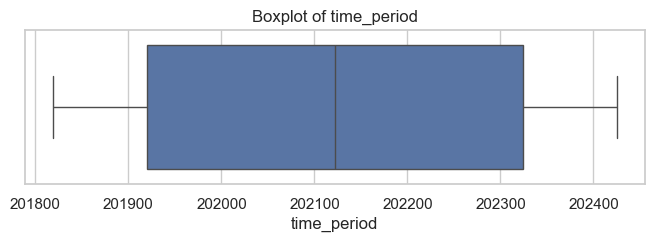

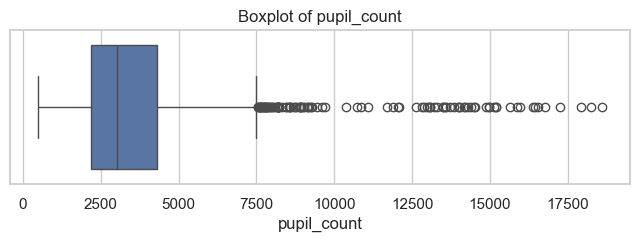

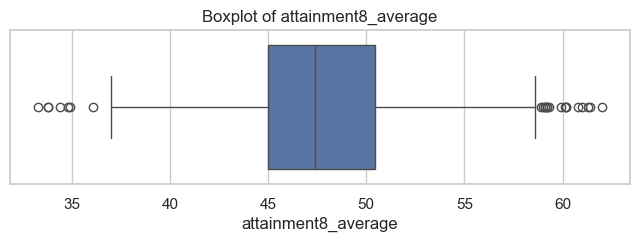

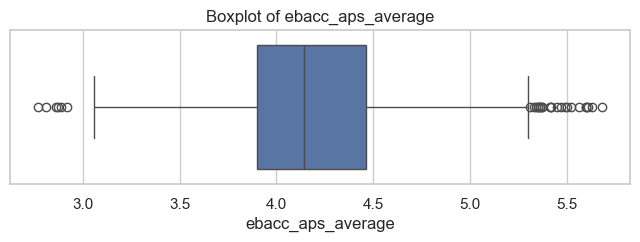

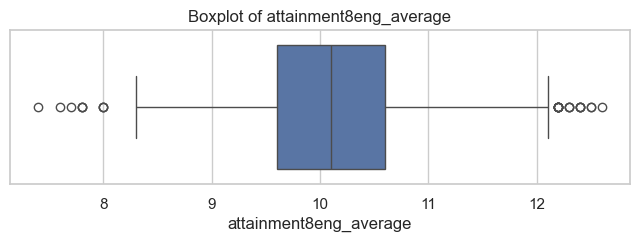

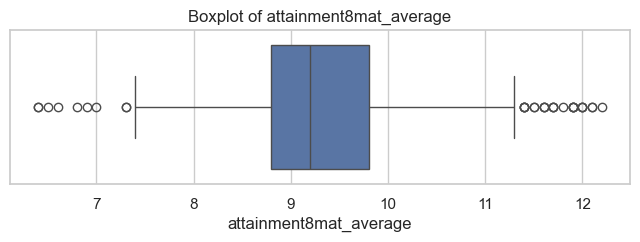

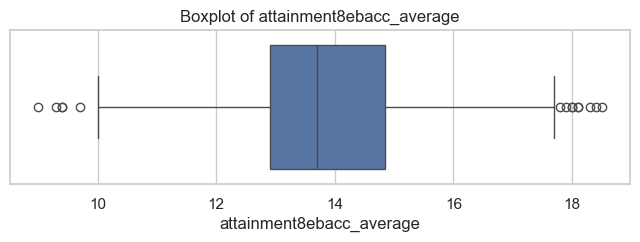

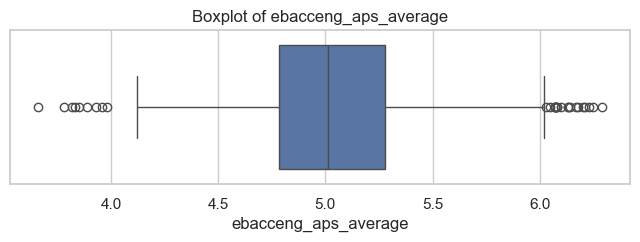

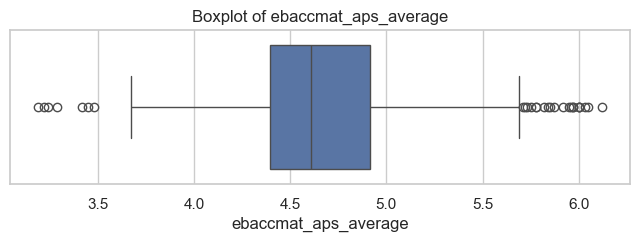

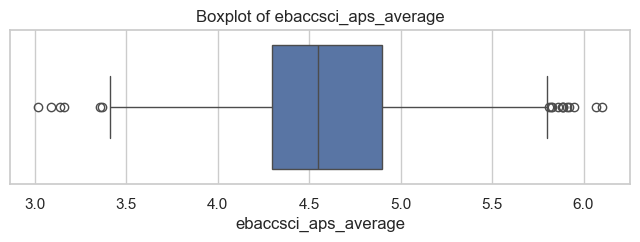

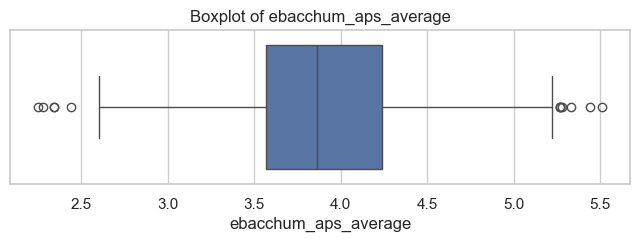

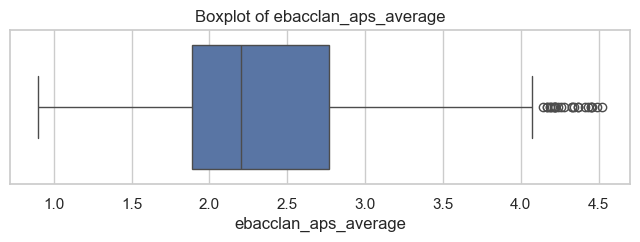

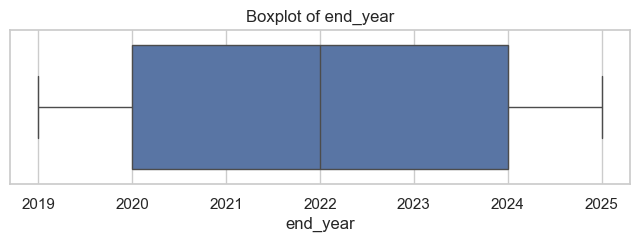

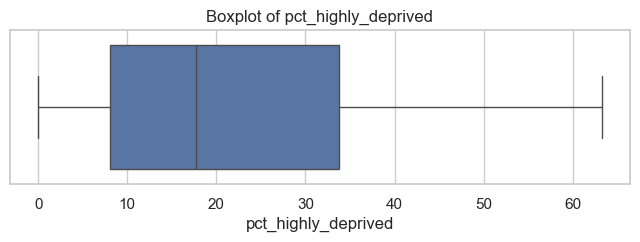

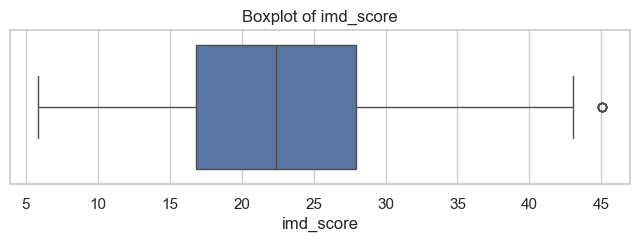

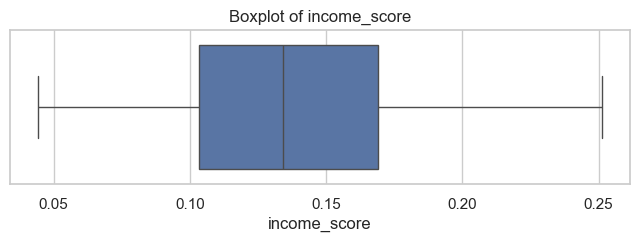

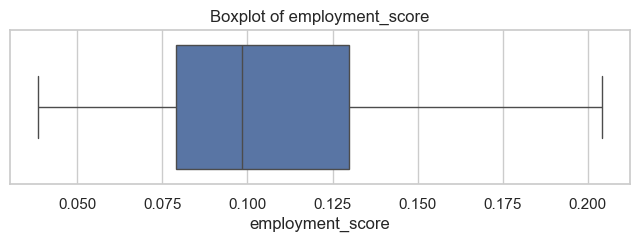

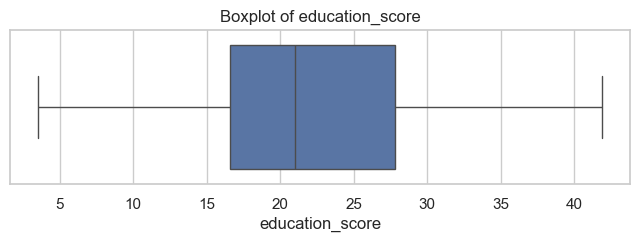

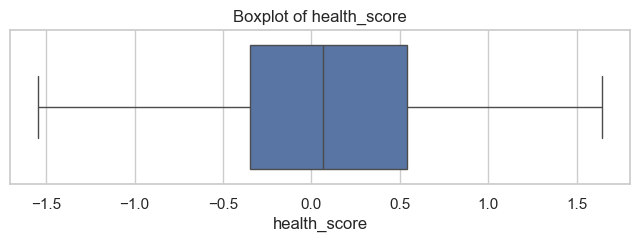

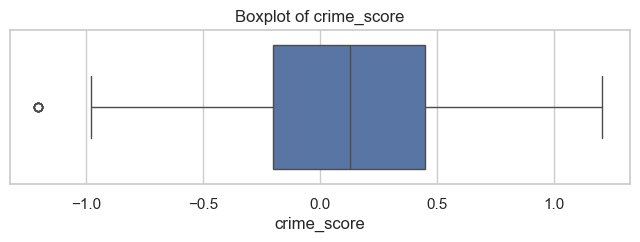

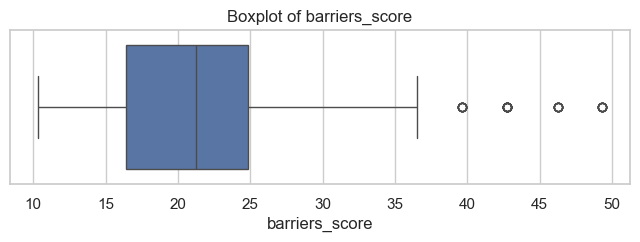

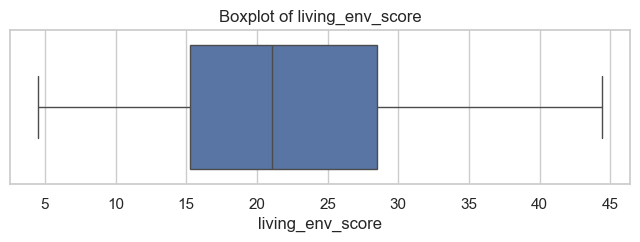

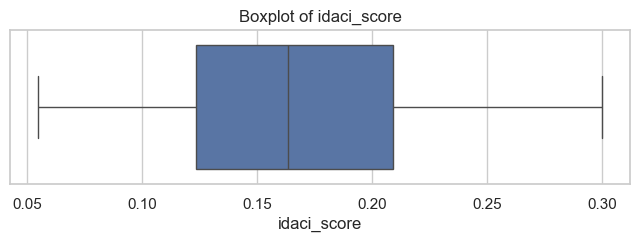

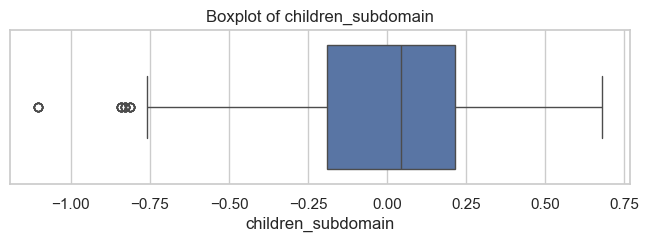

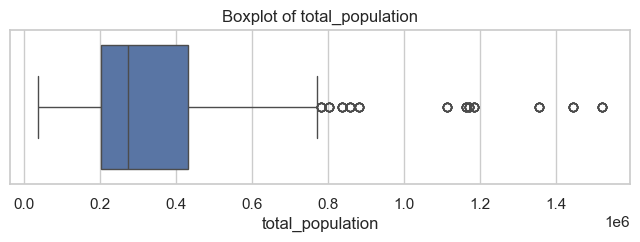

In [336]:
# Exploratory Data Analysis
sns.set_theme(style="whitegrid")

exploring_numeric_df = final_df_total.select_dtypes(exclude=['object'])

for column in exploring_numeric_df.columns:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=exploring_numeric_df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

### Interpreting the boxplots

It is important firstly to note the differences in scales between the different boxplots. Some of these differences are evident - year, pupil count etc. However, several calculated scores appear to be normalised to be on a centred z-score-type scale (roughly -1.5 to +1.5), including `children_subdomain`, `health_score`, and `crime_score`. However, other deprivation scores do not appear to be normalised: `imd_score`, `barriers_score`, `living_env_score` are on raw scales (ranging from 5-50). These will need to be appropriately scaled.

#### Outliers

Several outliers can be observed in the above boxplots. Of most note are:

- imd_score: There is a single point significantly visually separated from the rest. This is likely to be a high leverage point and may distort any analysis of correlation between this measure and any educational outcomes. It is important to identify this single point and run regressions with and without this single point to see whether it changes the conclusions.

- barriers_score: There is a cluster of a few outliers close together. This is worth investigating as a sub-group of note - it could be, for example, a group of London LA's, where it is sometimes claimed that there is high achievement versus deprivation, or some other grouping of LA's with common features that may also show commonalities in educational outcomes. So it is worth investigating this sub-group further.

- children_subdomain: There is a single very low reading, and another cluster of slightly less negative values. Both the invidual outlier and sub-group may also show structural differences in these LA performances and should be investigated further.

- Outliers in the educational outcomes tend to be on the upper end of the scale. It is worth investigating these by year, as our timeframe included the Covid years when teacher assessed grades were in some cases inflated and caused a distortion in the grade boundaries and outcomes. As with the deprivation outliers, it is also useful to investigate if any of these are consistently associated with specific LA's. 

In [337]:
# Outliers identification
def get_outliers(df, column, id_cols=['la_name', 'end_year']):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[column] < lower) | (df[column] > upper)
    return df.loc[mask, id_cols + [column]].sort_values(column)

cols_to_check = ['imd_score', 'children_subdomain', 'barriers_score', 'attainment8_average', 'ebacc_aps_average', 'attainment8mat_average', 'ebaccsci_aps_average', 'ebacclan_aps_average']
outlier_frames = []
for col in cols_to_check:
    out = get_outliers(final_df_total, col)
    out['outlier_column'] = col
    outlier_frames.append(out)

all_outliers = pd.concat(outlier_frames)

# Drop to one row per LA per outlier column, since these scores don't vary by year
all_outliers_unique = all_outliers.drop_duplicates(subset=['la_name', 'outlier_column'])

# Pivot so each LA is one row, with a column per deprivation measure
outlier_summary = (
    all_outliers_unique
    .pivot_table(index='la_name', columns='outlier_column',
                  values=['imd_score', 'children_subdomain', 'barriers_score', 'attainment8_average', 'ebacc_aps_average', 'attainment8mat_average', 'ebaccsci_aps_average', 'ebacclan_aps_average'],
                  aggfunc='first')
)
outlier_summary


,attainment8_average,attainment8mat_average,barriers_score,children_subdomain,ebacc_aps_average,ebacclan_aps_average,ebaccsci_aps_average,imd_score
outlier_column,attainment8_average,attainment8mat_average,barriers_score,children_subdomain,ebacc_aps_average,ebacclan_aps_average,ebaccsci_aps_average,imd_score
la_name,,,,,,,,
Barking and Dagenham,NaN,NaN,46.252024,NaN,NaN,NaN,NaN,NaN
Barnet,60.1,11.4,NaN,NaN,5.34,4.17,5.89,NaN
Blackpool,34.8,6.9,NaN,NaN,2.86,NaN,3.36,45.038551
Brent,NaN,NaN,42.783108,NaN,NaN,NaN,NaN,NaN
Buckinghamshire,59.0,11.5,NaN,NaN,NaN,NaN,NaN,NaN
Enfield,NaN,NaN,39.665895,NaN,NaN,NaN,NaN,NaN
Hackney,NaN,NaN,42.744868,NaN,NaN,4.24,NaN,NaN
Hammersmith and Fulham,NaN,NaN,NaN,NaN,5.35,4.14,NaN,NaN


These outliers begin to show us two really interesting points. There are two general clusters:

1. Barnet, Kingston upon Thames, Sutton, Trafford: These are low-deprivation, high attainment LA's. Most are rich London suburbs, with several well known private schools as well as grammar school provision.
2. Blackpool, Knowsley: These LAs show as having high levels of deprivation, while being outliers on the low end for one or more educational outcomes. 

So, this suggests that on the tails of our data, even before we get to investigating specific overall trends, that deprivation tends to be correlated with lower educational achievement, while wealth is correlated with higher educational outcomes.